In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [22]:
import os.path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import h5py
import numpy as np

from astropy.time import Time
from astropy.time import TimeDelta
from astropy import units as u
from astropy import constants as const

import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
from matplotlib import ticker

from scipy.signal import stft, butter, filtfilt
from scipy.signal import find_peaks_cwt
from scipy import signal
from scipy.fft import fft, rfft, fftfreq, rfftfreq

from lsst_efd_client import EfdClient
from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState, TMAEvent
from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient
from lsst.ts.xml.enums import MTM1M3, MTMount
import read_hdf

In [3]:
client = EfdClient("usdf_efd")

In [4]:
date_dict = {
    "date": "2026-03-09",
    "start_time": "17:12:00.00",
    "end_time": "17:14:00.00",
}
date = date_dict["date"]
start_time = Time(f"{date} {date_dict['start_time']}")
end_time = Time(f"{date} {date_dict['end_time']}")

In [5]:
start_time

<Time object: scale='utc' format='iso' value=2026-03-09 17:12:00.000>

In [6]:
df_mtm1m3_dst = getEfdData(
    client, "lsst.sal.MTM1M3.logevent_detailedState", begin=start_time, end=end_time
)

In [7]:
df_mtm1m3_dst

""


In [8]:
def vms_data_to_pandas(filename, vms_type, begin_time=None, end_time=None):
    """
    Converts VMS data in the given HDF5 file to a Pandas DataFrame.

    Args:
    filename: Path to the HDF5 file containing the VMS data.
    vms_type: The type of VMS data in the file. Must be "m1m3", "m2", or
      "rotator".
    begin_time: The start time of the data to include in the DataFrame. If None,
      all data will be included.
    end_time: The end time of the data to include in the DataFrame. If None, all
      data will be included.

    Returns:
    A Pandas DataFrame containing the VMS data.
    """
    if vms_type == "m1m3":
        key_dict = key_m1m3_dict
    elif vms_type == "m2":
        key_dict = key_m2_dict
    elif vms_type == "rotator":
        key_dict = key_rotator_dict
    else:
        raise ValueError("vms_type must be m1m3,m2, or rotator")

    f = h5py.File(filename, "r")
    times = f["timestamp"][::1]
    dkeys = "XYZ"

    data_dict = {}
    if (begin_time is not None) & (end_time is not None):
        sel = (times > begin_time) & (times < end_time)
    else:
        sel = np.ones(times.size).astype(bool)
    data_dict["times"] = times[sel]
    for key in key_dict.keys():
        # multiply values stored in hdf5 files by 2 in order to convert the acceleration values to mg
        data_dict[key_dict[key]] = f[key][::1][sel] * 2.0
    data_frame = pd.DataFrame(data_dict)
    for j in np.arange(int(len(key_dict) / 3)) + 1:
        data_frame[f"total_{j}"] = np.linalg.norm(
            data_frame[[f"{vms_type}_{i}_{j}" for i in ["x", "y", "z"]]].values, axis=1
        )

    return data_frame

In [9]:
system = "M1M3"
vms_date = "2026-03-09"
vms_top_dir = "/home/h/hyeyun/vmsdata"
year, month = vms_date.split("-")[0:2]

# Directory containing VMS data
vms_dir = os.path.join(vms_top_dir, year, month)

# Check if a parquet file exists
vms_mx_parquet_filename = os.path.join(vms_dir, f"{system}-" + vms_date + "T00:00.parquet")
if os.path.isfile(vms_mx_parquet_filename):
    print(f"Reading VMS data from parquet file:{vms_mx_parquet_filename}")
    vms_m1m3_data = pd.read_parquet(vms_mx_parquet_filename)
else:
    print("Parquet file not found")

# Try to avoid that corrections in the next cell to be applied more than 1 time
applied_corrections_m1m3 = False

# Check that the corrections has not been applied already
if applied_corrections_m1m3 == False:

    # Subtract 37s to timestamps in order to take into account the difference between the TAI and UTC
    vms_m1m3_data.times = vms_m1m3_data.times - pd.Timedelta(value=37, unit="seconds")
    
    # Convert acceleration from milli-g to m/s²
    #for sensor in range(3):
    #    for axis in "xyz":
    #        key = f"{system.lower()}_{axis}_{sensor+1}"
    #        vms_mx_data[key] = 1e-3 * 9.8 * vms_mx_data[key]

    applied_corrections_m1m3 = True
else:
    print("Corrections have already been applied for M1M3 - Skipped")

Reading VMS data from parquet file:/home/h/hyeyun/vmsdata/2026/03/M1M3-2026-03-09T00:00.parquet


In [10]:
# Create a datetime index
vms_m1m3_data = vms_m1m3_data.set_index('times')

In [11]:
start = pd.Timestamp(start_time.unix, unit="s")
end = pd.Timestamp(end_time.unix, unit="s") + pd.Timedelta(value=60, unit="seconds")
print(start, end)

2026-03-09 17:12:00 2026-03-09 17:15:00


In [12]:
cut = (vms_m1m3_data.index >= start) & (vms_m1m3_data.index < end)

In [13]:
start_ext = pd.Timestamp(start_time.unix, unit="s") - pd.Timedelta(value=60, unit="seconds")
end_ext = pd.Timestamp(end_time.unix, unit="s") + pd.Timedelta(value=3, unit="hours")
print(start_ext, end_ext)

cut_ext = (vms_m1m3_data.index >= start_ext) & (vms_m1m3_data.index < end_ext)

2026-03-09 17:11:00 2026-03-09 20:14:00


In [14]:
t1 = Time("2026-03-09 06:09:00.000")
t2 = Time("2026-03-09 06:13:00.000")

In [15]:
df_mtm1m3_af = getEfdData(
    client, "lsst.sal.MTM1M3.appliedForces", 
    columns = ["fx", "fy", "fz", "mx", "my", "mz"],
    begin=t1, end=t2
)
df_mtm1m3_ims = getEfdData(
    client, "lsst.sal.MTM1M3.imsData",
    begin=t1, end=t2
)

In [16]:
t_start = pd.Timestamp(t1.unix, unit="s") 
t_end = pd.Timestamp(t2.unix, unit="s") 

cut = (vms_m1m3_data.index >= t_start) & (vms_m1m3_data.index < t_end)

In [17]:
df_mtm1m3_af

,fx,fy,fz,mx,my,mz
2026-03-09 06:09:00.007112+00:00,-25.885834,115556.835938,128767.617188,1436.933105,-558.279114,-1143.025024
2026-03-09 06:09:00.027318+00:00,-23.869797,115559.117188,128755.421875,1414.553467,-509.364716,-1147.447754
2026-03-09 06:09:00.047914+00:00,-26.154404,115556.718750,128733.468750,1414.186768,-519.220459,-1141.608643
2026-03-09 06:09:00.068835+00:00,-23.594864,115556.531250,128763.367188,1408.173096,-459.252625,-1139.721802
2026-03-09 06:09:00.088929+00:00,-25.750198,115556.484375,128734.437500,1416.177734,-498.901672,-1146.581543
...,...,...,...,...,...,...
2026-03-09 06:12:59.918699+00:00,28.350433,95248.226562,144491.078125,858.915283,-529.527649,-1083.032593
2026-03-09 06:12:59.938703+00:00,26.915543,95248.179688,144441.312500,920.445801,-552.225708,-1108.789551
2026-03-09 06:12:59.958604+00:00,29.386169,95240.609375,144479.406250,876.154968,-525.531494,-1079.657349
2026-03-09 06:12:59.978902+00:00,31.989746,95247.875000,144469.312500,955.103088,-560.003906,-1094.994873


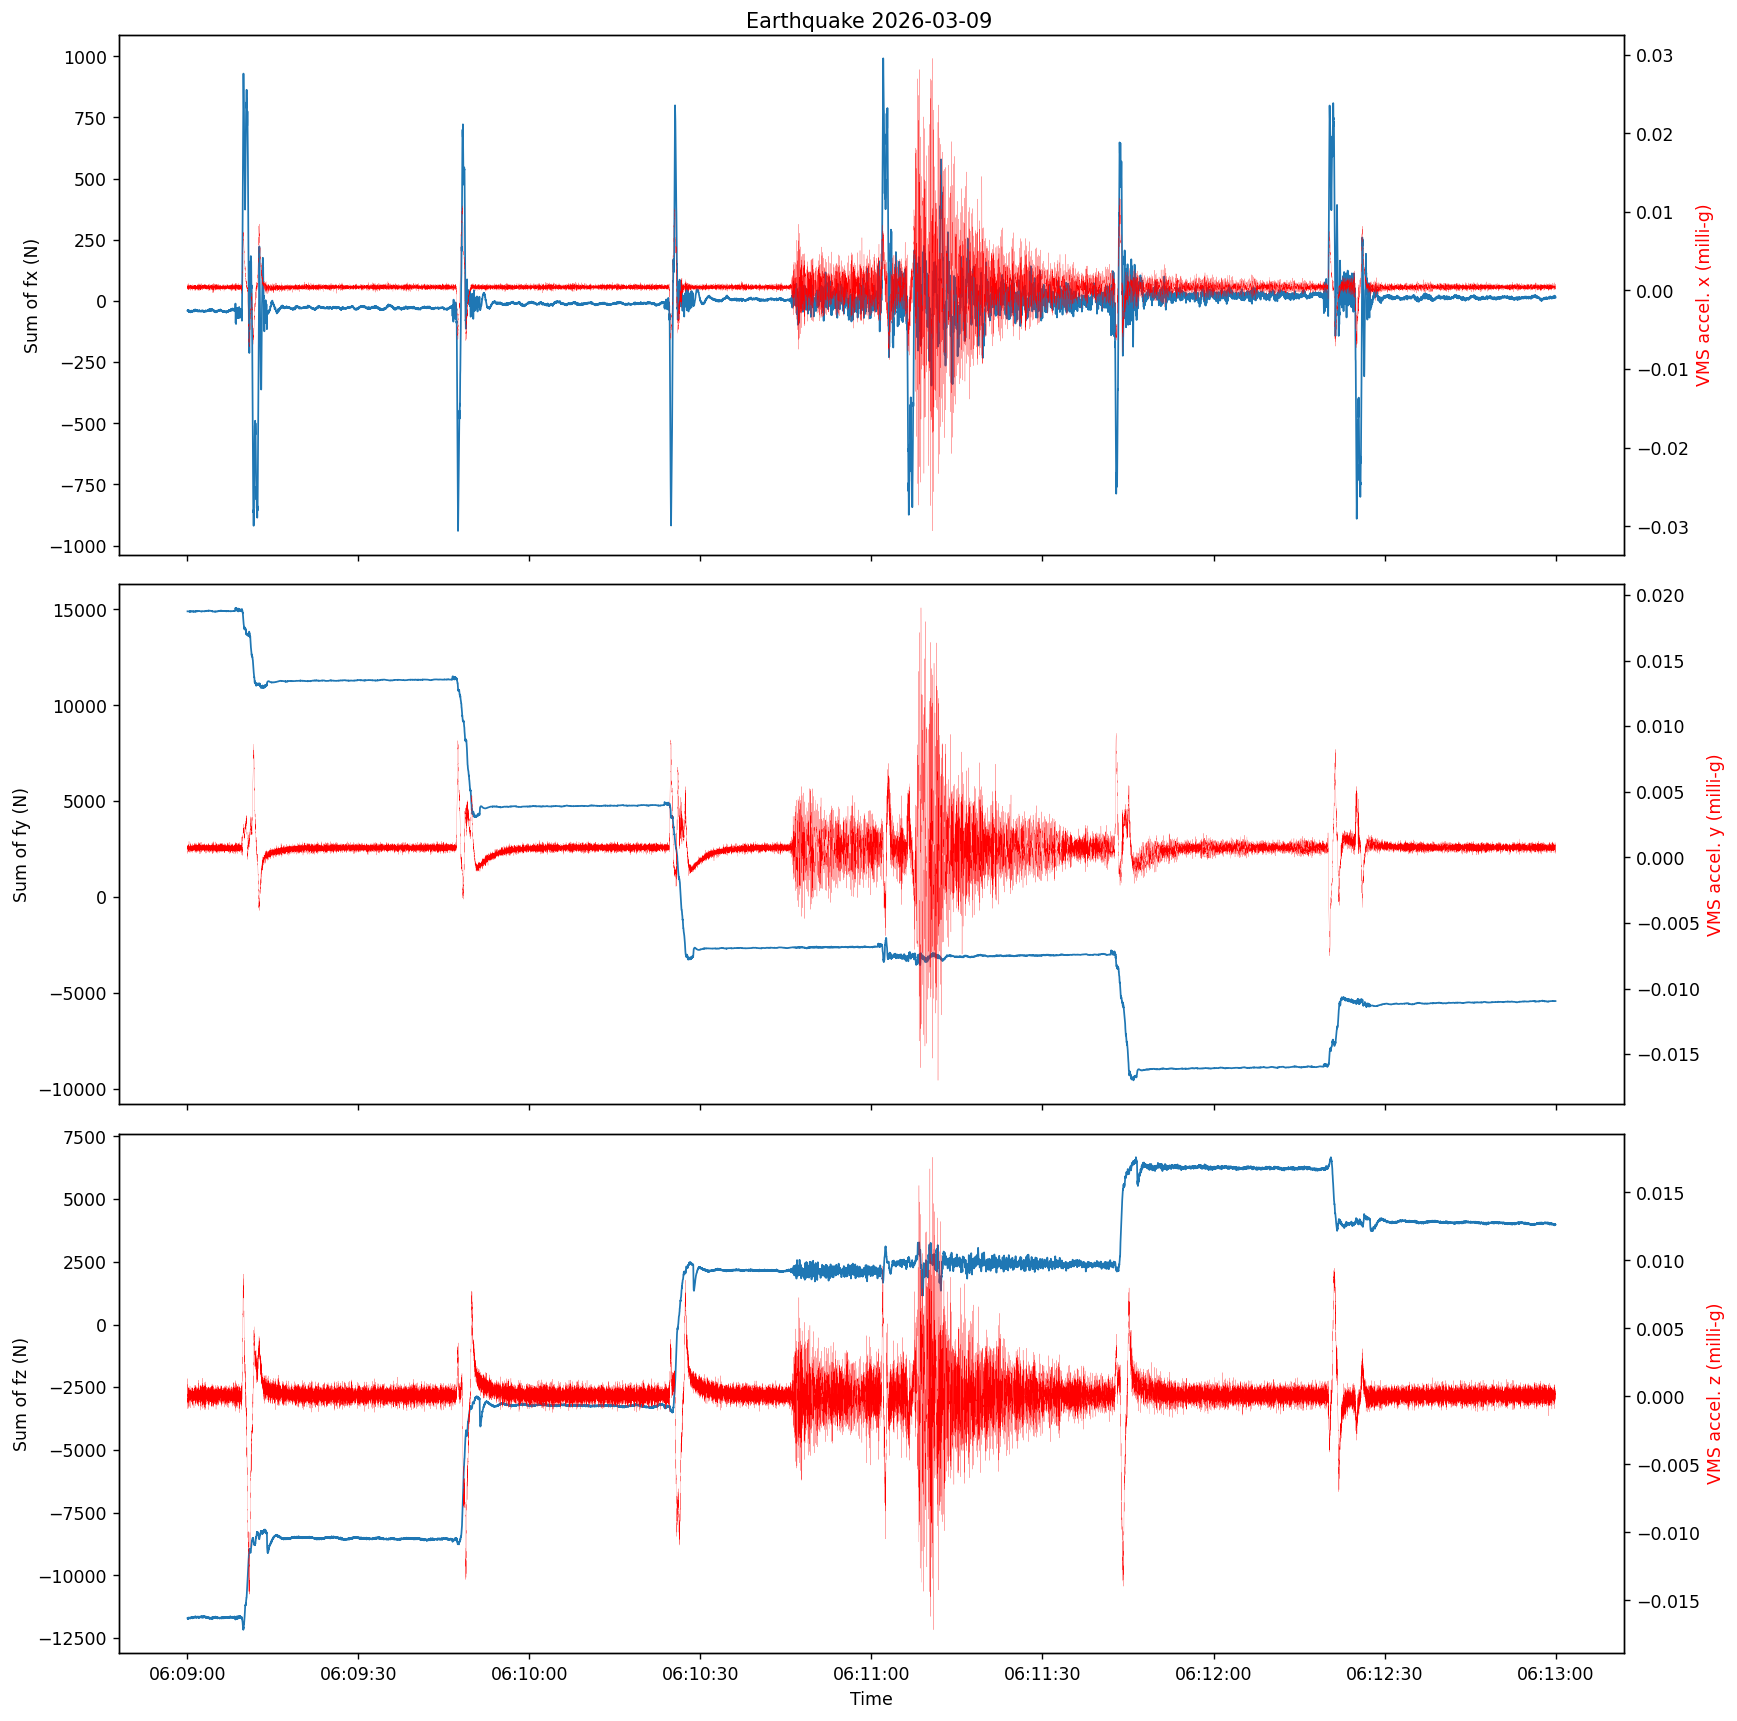

In [18]:
ax2 = [None]*3
fig, ax = plt.subplots(3, 1, sharex=True, dpi=125, figsize=(14, 14))
for i, axis in enumerate("xyz"):
    baseline = np.mean(df_mtm1m3_af[f"f{axis}"])
    ax[i].plot(df_mtm1m3_af.index, df_mtm1m3_af[f"f{axis}"]-baseline, lw=1)
    ax2[i] = ax[i].twinx()
    ax2[i].plot(vms_m1m3_data.index[cut], vms_m1m3_data[cut][f"m1m3_{axis}_1"], lw=0.1, c="red")
    ax[i].set_ylabel(f"Sum of f{axis} (N)")
    ax2[i].set_ylabel(f"VMS accel. {axis} (milli-g)", color="red")
    
ax[2].set_xlabel("Time")
        
fig.suptitle(f"Earthquake {date}")
fig.tight_layout()

In [19]:
vms_m1m3_data[cut]

,m1m3_x_1,m1m3_y_1,m1m3_z_1,m1m3_x_2,m1m3_z_2,m1m3_y_2,m1m3_x_3,m1m3_y_3,m1m3_z_3,total_1,total_2,total_3
times,,,,,,,,,,,,
2026-03-09 06:09:00.001868,0.000420,0.000481,-0.000014,0.000285,-0.000007,0.000498,0.000665,0.000522,0.000838,0.000639,0.000574,0.001190
2026-03-09 06:09:00.006868,0.000484,0.000298,0.000023,0.000145,-0.000469,0.000496,0.000656,0.000340,0.000309,0.000569,0.000698,0.000801
2026-03-09 06:09:00.011868,0.000767,0.000763,0.000179,0.000080,0.000179,0.000435,0.000870,0.000359,0.000107,0.001096,0.000477,0.000947
2026-03-09 06:09:00.016868,0.000359,0.000885,-0.000329,0.000353,0.000393,0.000458,0.000631,0.000420,-0.000054,0.001010,0.000699,0.000760
2026-03-09 06:09:00.021868,0.000191,0.000656,-0.000912,0.000427,-0.000412,0.000637,0.000305,0.000587,0.000584,0.001139,0.000871,0.000883
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 06:12:59.975486,0.000515,0.000832,-0.000282,0.000347,0.000412,0.000584,0.000706,0.000614,0.000462,0.001018,0.000794,0.001043
2026-03-09 06:12:59.980486,0.000404,0.000871,0.000027,0.000292,-0.000156,0.000648,0.000519,0.000420,0.000149,0.000961,0.000727,0.000684
2026-03-09 06:12:59.985486,0.000370,0.000862,0.000240,0.000328,-0.001045,0.000690,0.000412,0.000496,0.000107,0.000968,0.001295,0.000654


In [20]:
df_mtm1m3_ims

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,rawSensorData0,rawSensorData1,...,rawSensorData5,rawSensorData6,rawSensorData7,timestamp,xPosition,xRotation,yPosition,yRotation,zPosition,zRotation
2026-03-09 06:09:00.004207+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11910558,1.773037e+09,0.030715,0.040452,...,0.024057,0.029286,0.023930,1.773037e+09,-0.000045,0.000964,-0.000103,-0.001816,-0.00019,-0.000191
2026-03-09 06:09:00.024963+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11910559,1.773037e+09,0.030715,0.040452,...,0.024057,0.029286,0.023930,1.773037e+09,-0.000045,0.000964,-0.000103,-0.001816,-0.00019,-0.000191
2026-03-09 06:09:00.045578+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11910560,1.773037e+09,0.030715,0.040452,...,0.024057,0.029286,0.023930,1.773037e+09,-0.000045,0.000967,-0.000103,-0.001816,-0.00019,-0.000191
2026-03-09 06:09:00.086386+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11910561,1.773037e+09,0.030715,0.040452,...,0.024057,0.029286,0.023930,1.773037e+09,-0.000045,0.000964,-0.000103,-0.001816,-0.00019,-0.000191
2026-03-09 06:09:00.107566+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11910562,1.773037e+09,0.030715,0.040452,...,0.024057,0.029286,0.023930,1.773037e+09,-0.000045,0.000967,-0.000103,-0.001816,-0.00019,-0.000191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 06:12:59.893969+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11920463,1.773037e+09,0.030733,0.040456,...,0.024060,0.029296,0.023935,1.773037e+09,-0.000041,0.001070,-0.000100,-0.001823,-0.00018,-0.000197
2026-03-09 06:12:59.916351+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11920464,1.773037e+09,0.030733,0.040456,...,0.024060,0.029296,0.023935,1.773037e+09,-0.000041,0.001070,-0.000100,-0.001823,-0.00018,-0.000197
2026-03-09 06:12:59.936297+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11920465,1.773037e+09,0.030733,0.040456,...,0.024060,0.029296,0.023935,1.773037e+09,-0.000041,0.001070,-0.000100,-0.001823,-0.00018,-0.000197
2026-03-09 06:12:59.976398+00:00,1.773037e+09,MTM1M3,1.773037e+09,4799,0,52fa322f,11920466,1.773037e+09,0.030733,0.040456,...,0.024060,0.029296,0.023935,1.773037e+09,-0.000041,0.001070,-0.000100,-0.001823,-0.00018,-0.000197


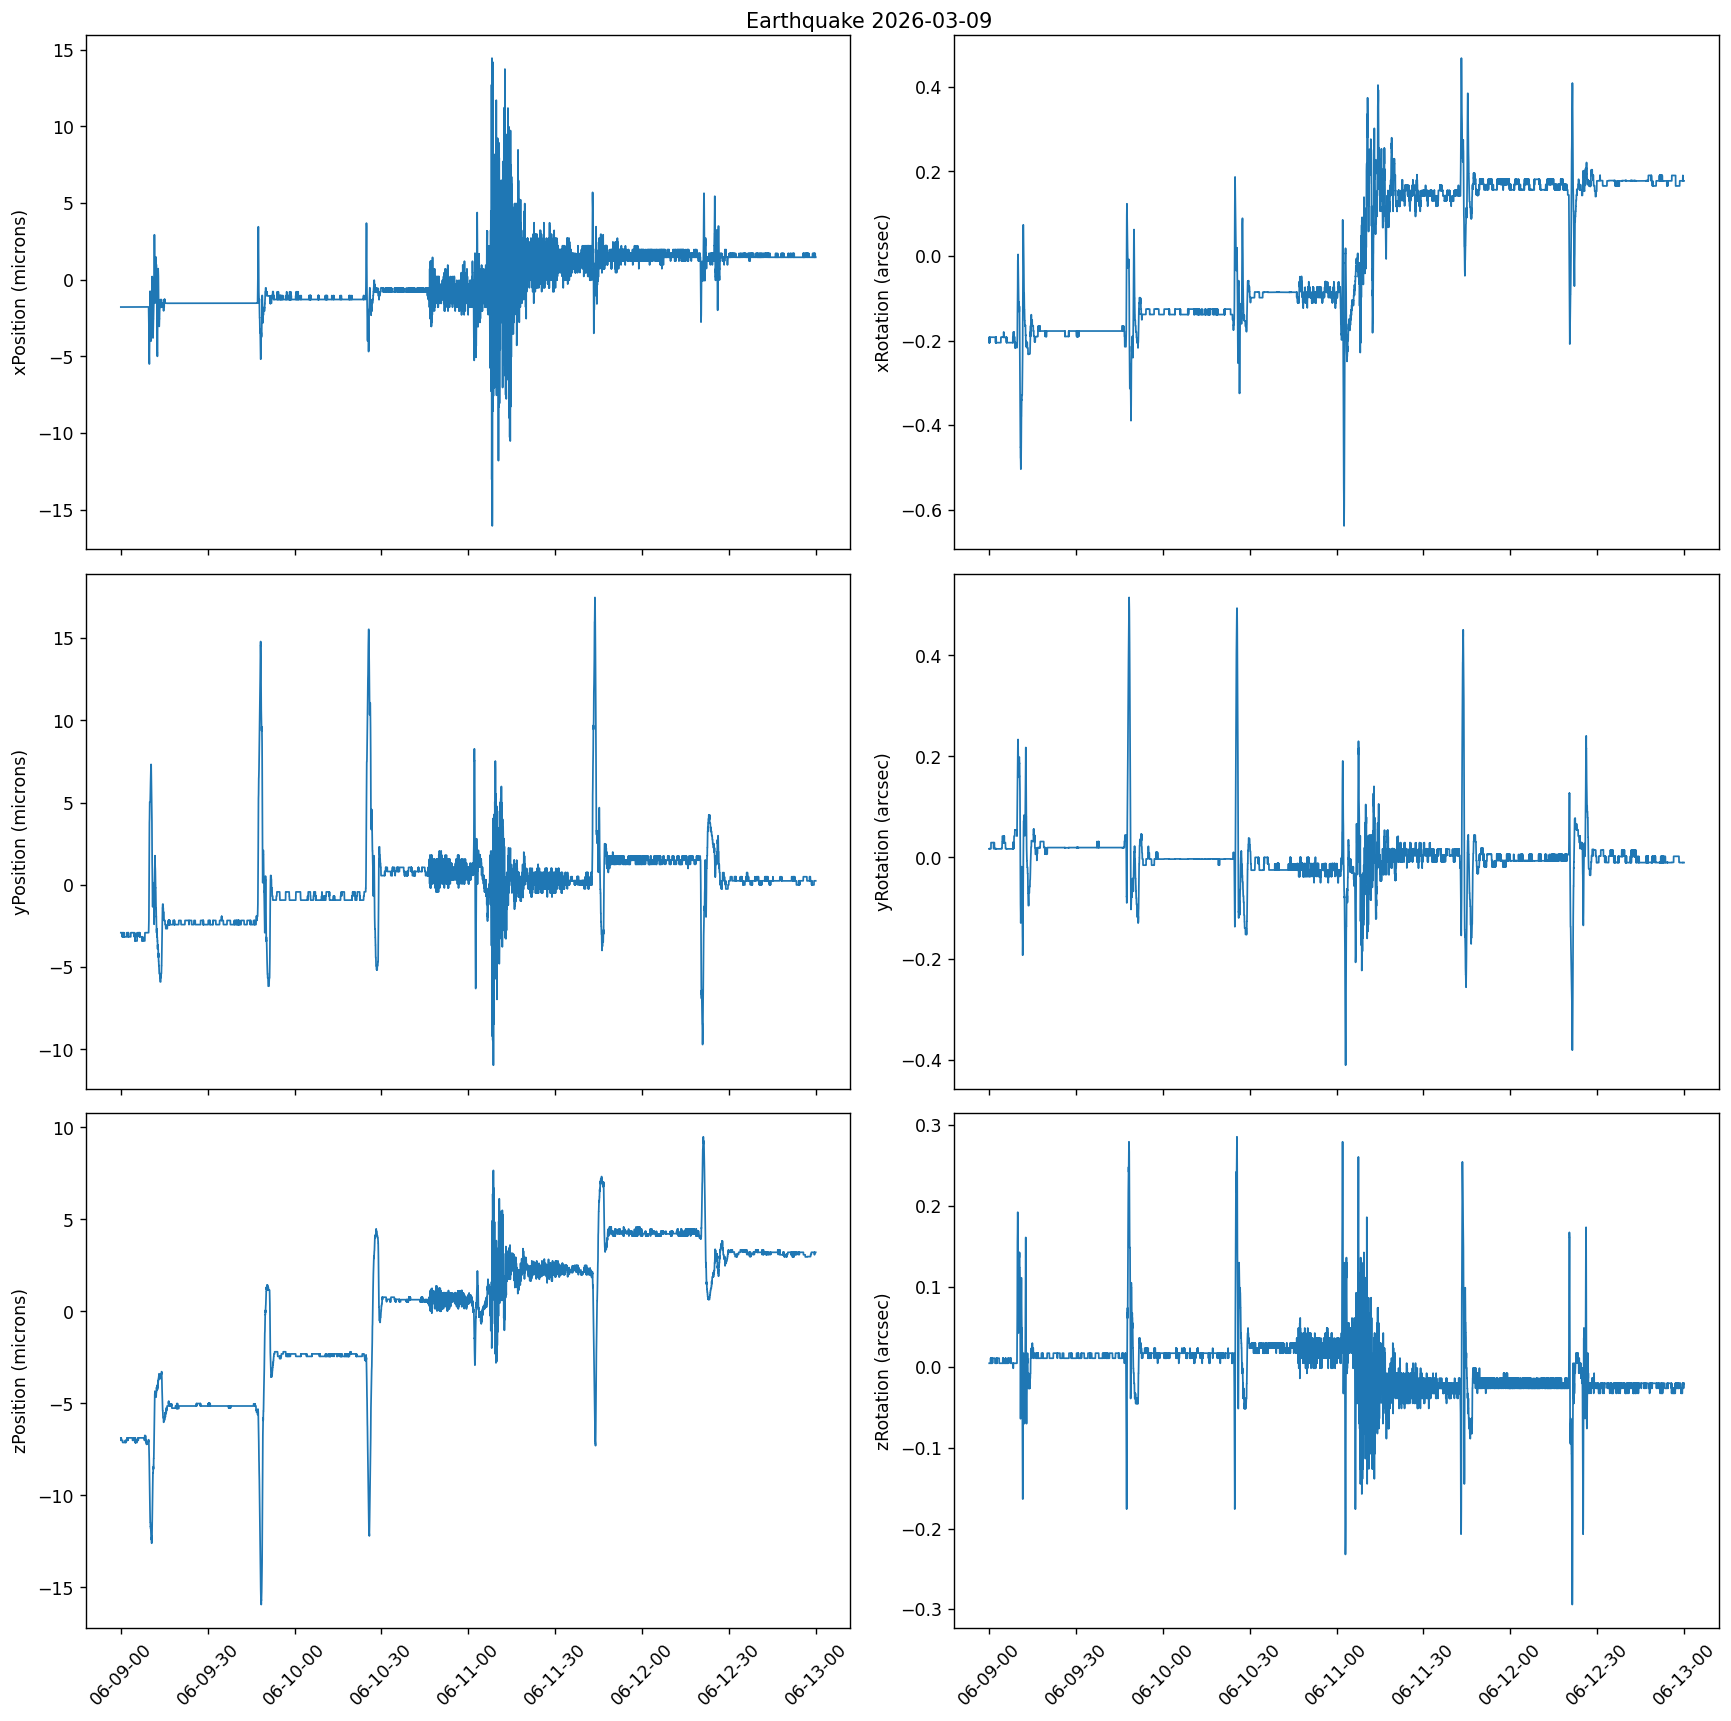

In [21]:
ax2 = [None]*3
fig, ax = plt.subplots(3, 2, sharex=True, dpi=125, figsize=(14, 14))
for i, axis in enumerate("xyz"):
    base_pos = np.mean(df_mtm1m3_ims[f"{axis}Position"])
    ax[i][0].plot(df_mtm1m3_ims.index, (df_mtm1m3_ims[f"{axis}Position"]-base_pos)*1.e6, lw=1)
    ax[i][0].set_ylabel(f"{axis}Position (microns)")
    base_rot = np.mean(df_mtm1m3_ims[f"{axis}Rotation"])
    ax[i][1].plot(df_mtm1m3_ims.index, (df_mtm1m3_ims[f"{axis}Rotation"]-base_rot)*3600, lw=1)
    ax[i][1].set_ylabel(f"{axis}Rotation (arcsec)")
    #ax[i][0].set_ylim([-200, 200])
    #ax[i][1].set_ylim([-10, 10])

for j in range(2):
    ax[2][j].xaxis.set_major_formatter(DateFormatter("%H-%M-%S"))
    plt.setp(ax[2][j].get_xticklabels(), rotation=45)
        
fig.suptitle(f"Earthquake {date}")
fig.tight_layout()